In [33]:
import numpy as np 
import matplotlib.pyplot as plt 

In [34]:
def cost(x,t,I=None):
    k = len(x)
    if I is None:
        I = np.arange(k)        
    w = np.sort(np.random.dirichlet(np.ones(k),size=1))[0]
    w_ = np.empty_like(w)
    w_[I] = w
    dim_cost = []
    for i in range(k):
        ell = 1/(w_[i]*t+1)
        f_x_t = ell*np.exp(-(np.abs(x[i])*ell))
        dim_cost.append(1-f_x_t)
    return np.prod(np.array(dim_cost))

In [35]:
def generate_2d_mesh(x_min=0, x_max=1, y_min=0, y_max=1, num_x=30, num_y=30):
    x = np.linspace(x_min, x_max, num_x)
    y = np.linspace(y_min, y_max, num_y)
    xx, yy = np.meshgrid(x, y)
    points = np.vstack([xx.ravel(), yy.ravel()]).T

    return points

def plot_contour(X, Z):
    x_unique = np.unique(X[:, 0])
    y_unique = np.unique(X[:, 1])
    X_grid = x_unique
    Y_grid = y_unique

    # Reshape Z to match mesh shape
    Z_grid = Z.reshape(len(y_unique), len(x_unique))  # Note: y first, x second due to row-major order

    # Create contour plot
    fig, ax = plt.subplots()
    contour = ax.contourf(X_grid, Y_grid, Z_grid, cmap='coolwarm')
    plt.colorbar(contour, label='Cost')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.tight_layout()

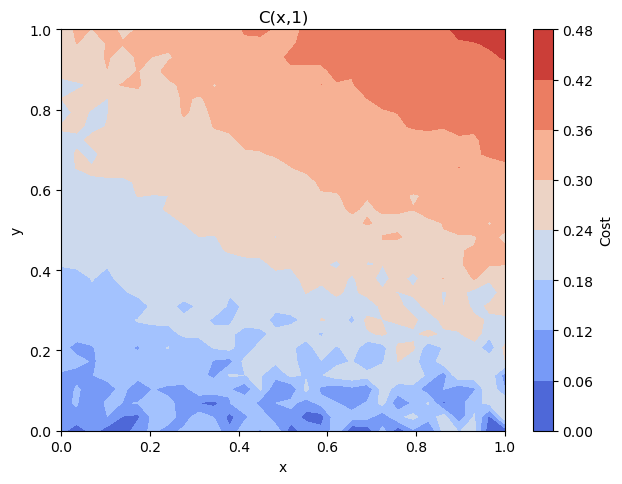

In [36]:
mesh_points = generate_2d_mesh(x_min=0, x_max=1, y_min=0, y_max=1)
cost_values = np.asarray([cost(p, 1, I = [1,0]) for p in mesh_points])
plot_contour(mesh_points, cost_values)
plt.title('C(x,1)')
plt.show()


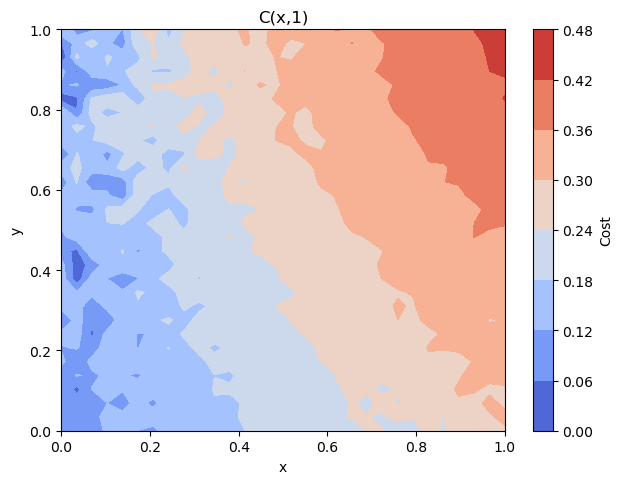

In [37]:
cost_values = np.asarray([cost(p, 1, I = [0,1]) for p in mesh_points])
plot_contour(mesh_points, cost_values)
plt.title('C(x,1)')
plt.show()

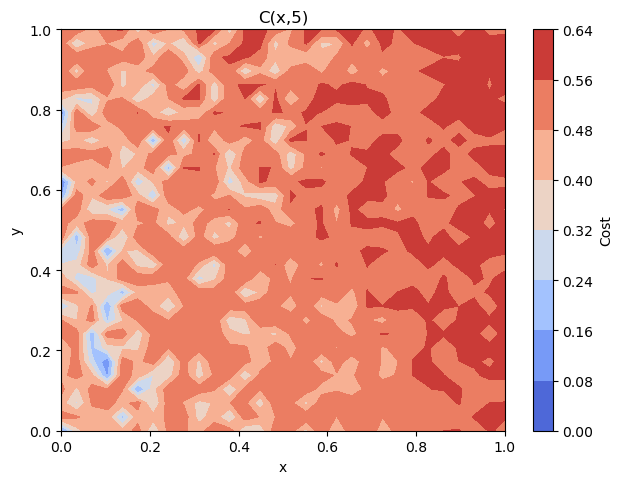

In [38]:
cost_values = np.asarray([cost(p, 5) for p in mesh_points])
plot_contour(mesh_points, cost_values)
plt.title('C(x,5)')
plt.show()

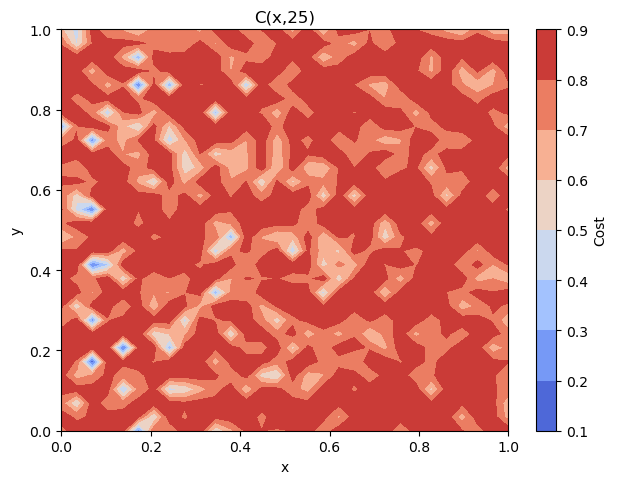

In [39]:
cost_values = np.asarray([cost(p, 25) for p in mesh_points])
plot_contour(mesh_points, cost_values)
plt.title('C(x,25)')
plt.show()

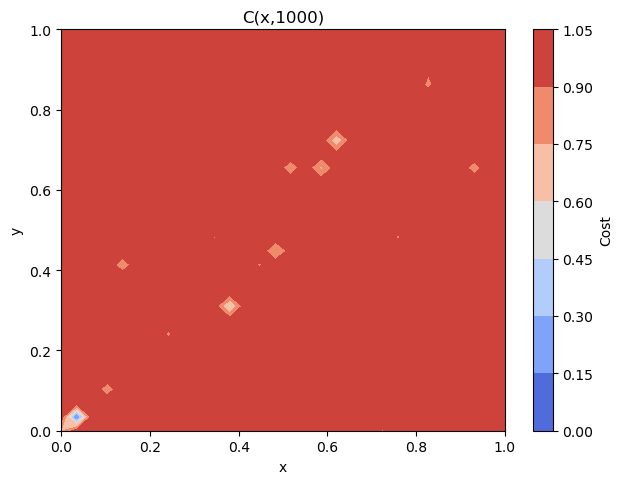

In [40]:
cost_values = np.asarray([cost(p, 1000) for p in mesh_points])
plot_contour(mesh_points, cost_values)
plt.title('C(x,1000)')
plt.show()